# Portfolio's Building #

### Rebalancing Weights ###

In [5]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Optimization
from scipy.optimize import minimize

# Visualization
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data
from portfolios_helper import calculate_analytics
from markowitz_portfolios_toolkit import markowitz_weights

In [6]:
tickers = get_tickers(mod="2.4")

tickers

['AAPL', 'AMZN', 'META', 'MSFT', 'NVDA']

In [7]:
# Import data
df_returns = pd.DataFrame()

for ticker in tickers:
    df = get_market_data(
        ticker=ticker, 
        start_date='2013-01-01', 
        end_date='2025-01-01', 
        returns=True
    )
    
    returns_series = df['returns'].rename(ticker)
    
    df_returns = pd.concat([df_returns, returns_series], axis=1)
    
    print(f'Data Ready for {ticker}')

df_returns.index.name = 'date'
df_returns.index = pd.to_datetime(df_returns.index)

Data Ready for AAPL
Data Ready for AMZN
Data Ready for META
Data Ready for MSFT
Data Ready for NVDA


In [8]:
df_returns

,AAPL,AMZN,META,MSFT,NVDA
date,,,,,
2013-01-03,-0.012703,0.004537,-0.008248,-0.013487,0.000786
2013-01-04,-0.028250,0.002589,0.035029,-0.018893,0.032461
2013-01-07,-0.005900,0.035295,0.022689,-0.001871,-0.029324
2013-01-08,0.002688,-0.007778,-0.012312,-0.005260,-0.022170
2013-01-09,-0.015753,-0.000113,0.051311,0.005634,-0.022673
...,...,...,...,...,...
2024-12-24,0.011413,0.017573,0.013084,0.009330,0.003930
2024-12-26,0.003171,-0.008770,-0.007266,-0.002781,-0.002070
2024-12-27,-0.013331,-0.014641,-0.005884,-0.017453,-0.021088


In [9]:
df_returns.mean()

AAPL    0.000897
AMZN    0.000939
META    0.001008
MSFT    0.000972
NVDA    0.002029
dtype: float64

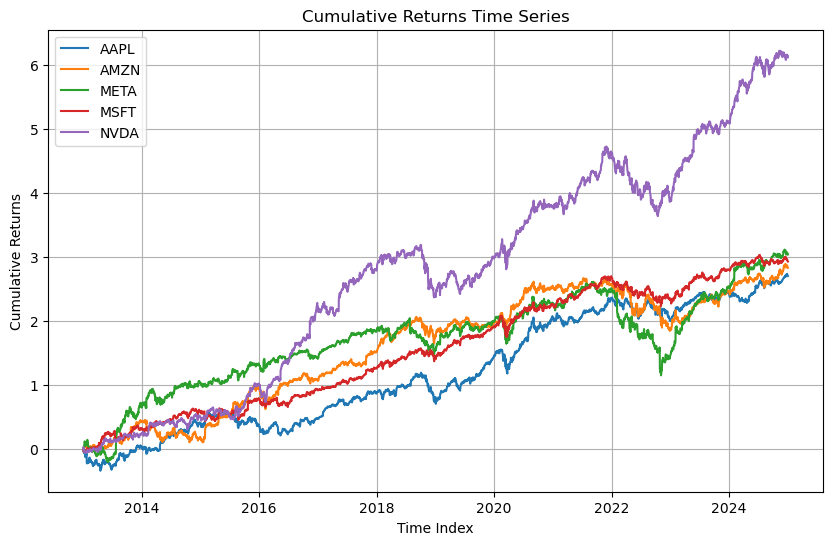

In [10]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(df_returns.cumsum(), label=df_returns.columns, alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Returns')
plt.legend()

# Show
plt.grid(True)
plt.show()

In [11]:
# Let us Calculate the Weights
def rolling_weights(
    returns, 
    desired_returns, 
    window=252, 
    rebalance_freq=126
):

    # Lists to Store Things
    weights_list = []
    dates = []

    for i in range(window, len(returns), rebalance_freq):
        past_returns = returns.iloc[i - window:i]  # Rolling Window
        past_excepted_returns = past_returns.mean()
        past_cov_matrix = past_returns.cov()

        # Calculate Weights
        w = markowitz_weights(past_excepted_returns, past_cov_matrix, desired_returns)

        # Save weights and dates
        weights_list.append(w)
        dates.append(returns.index[i])

    # Create the DataFrame
    weights_df = pd.DataFrame(weights_list, index=dates, columns=returns.columns)

    # Expand the DataFrame
    weights_df = weights_df.reindex(returns.index, method='ffill')

    return weights_df.dropna()

In [12]:
# Create the DataFrames of Returns
df_weights = rolling_weights(df_returns, 0.001)

df_weights

,AAPL,AMZN,META,MSFT,NVDA
date,,,,,
2014-01-03,0.248230,0.185377,0.016886,0.222273,0.327235
2014-01-06,0.248230,0.185377,0.016886,0.222273,0.327235
2014-01-07,0.248230,0.185377,0.016886,0.222273,0.327235
2014-01-08,0.248230,0.185377,0.016886,0.222273,0.327235
2014-01-09,0.248230,0.185377,0.016886,0.222273,0.327235
...,...,...,...,...,...
2024-12-24,0.421851,0.156492,-0.038090,0.517653,-0.057906
2024-12-26,0.421851,0.156492,-0.038090,0.517653,-0.057906
2024-12-27,0.421851,0.156492,-0.038090,0.517653,-0.057906


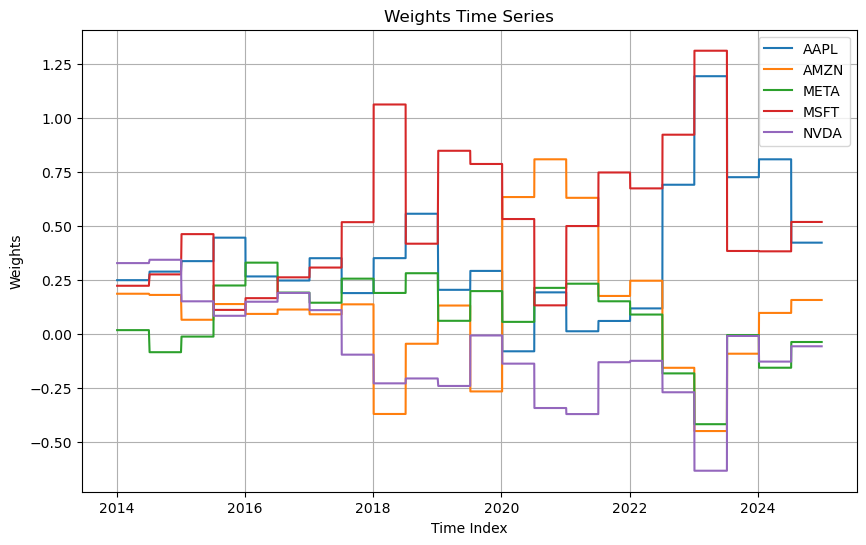

In [13]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(df_weights, label=df_weights.columns, alpha=1)
# Config
plt.title('Weights Time Series')
plt.xlabel('Time Index')
plt.ylabel('Weights')
plt.legend()

# Show
plt.grid(True)
plt.show()

In [14]:
# Common Index
common_index = df_returns.index.intersection(df_weights.index)
df_returns_reindex = df_returns.reindex(common_index)
df_weights = df_weights.reindex(common_index)

df_returns_reindex

,AAPL,AMZN,META,MSFT,NVDA
date,,,,,
2014-01-03,-0.022211,-0.003852,-0.002745,-0.006751,-0.012052
2014-01-06,0.005438,-0.007113,0.047253,-0.021359,0.013312
2014-01-07,-0.007177,0.011116,0.012509,0.007720,0.016240
2014-01-08,0.006313,0.009726,0.005338,-0.018014,0.013539
2014-01-09,-0.012852,-0.002267,-0.017497,-0.006453,-0.037999
...,...,...,...,...,...
2024-12-24,0.011413,0.017573,0.013084,0.009330,0.003930
2024-12-26,0.003171,-0.008770,-0.007266,-0.002781,-0.002070
2024-12-27,-0.013331,-0.014641,-0.005884,-0.017453,-0.021088


In [15]:
# Create the Portfolio Returns
df_weighted_returns = df_returns_reindex * df_weights

df_weighted_returns

,AAPL,AMZN,META,MSFT,NVDA
date,,,,,
2014-01-03,-0.005513,-0.000714,-0.000046,-0.001500,-0.003944
2014-01-06,0.001350,-0.001319,0.000798,-0.004748,0.004356
2014-01-07,-0.001781,0.002061,0.000211,0.001716,0.005314
2014-01-08,0.001567,0.001803,0.000090,-0.004004,0.004430
2014-01-09,-0.003190,-0.000420,-0.000295,-0.001434,-0.012434
...,...,...,...,...,...
2024-12-24,0.004814,0.002750,-0.000498,0.004830,-0.000228
2024-12-26,0.001338,-0.001372,0.000277,-0.001439,0.000120
2024-12-27,-0.005624,-0.002291,0.000224,-0.009035,0.001221


In [16]:
# Create the Portfolio Returns
df_returns_portfolio = df_returns.copy()

# Add the columns
df_returns_portfolio['Portfolio'] =  df_weighted_returns.sum(axis = 1)

df_returns_portfolio['Portfolio'].dropna()

date
2014-01-03   -0.011718
2014-01-06    0.000438
2014-01-07    0.007521
2014-01-08    0.003886
2014-01-09   -0.017775
                ...   
2024-12-24    0.011668
2024-12-26   -0.001078
2024-12-27   -0.015504
2024-12-30   -0.013909
2024-12-31   -0.006683
Name: Portfolio, Length: 2767, dtype: float64

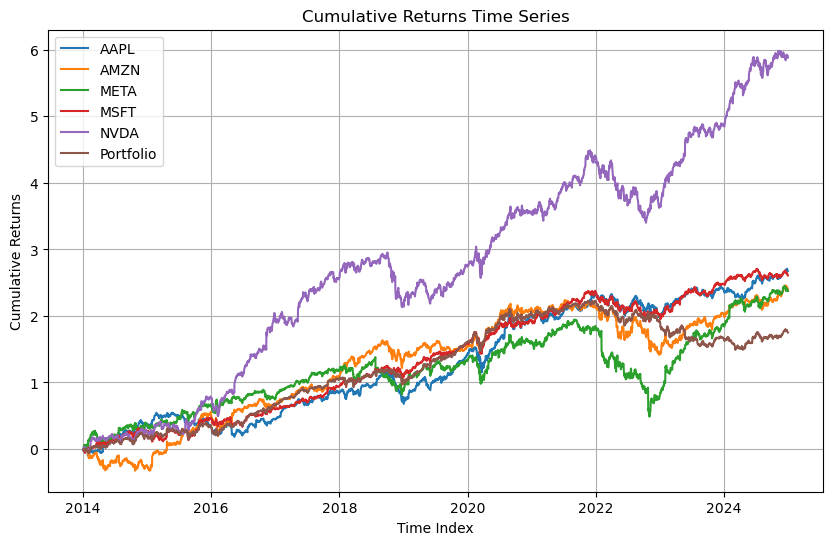

In [17]:
# Time Series Graphs
df_plot = df_returns_portfolio.dropna()

plt.figure(figsize=(10, 6))
plt.plot(df_plot.cumsum(), label=df_plot.columns, alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Returns')
plt.legend()

# Show
plt.grid(True)
plt.show()

### Define different rebalancing frequencies ###

In [18]:
# Desired Return
dr = 0.001

In [19]:
# Create weights for different re-balancing frequencies
df_weights_5d = rolling_weights(df_returns, dr, rebalance_freq=5)
df_weights_21d = rolling_weights(df_returns, dr, rebalance_freq=21)
df_weights_63d = rolling_weights(df_returns, dr, rebalance_freq=63)
df_weights_126d = rolling_weights(df_returns, dr, rebalance_freq=126)
df_weights_252d = rolling_weights(df_returns, dr, rebalance_freq=252)

In [20]:
# Create the Returns
df_weighted_returns_5d = df_returns * df_weights_5d
df_weighted_returns_21d = df_returns * df_weights_21d
df_weighted_returns_63d = df_returns * df_weights_63d
df_weighted_returns_126d = df_returns * df_weights_126d
df_weighted_returns_252d = df_returns * df_weights_252d

In [21]:
# Add the columns
portfolios_df = pd.DataFrame(index = df_returns.loc['2016':].index)

portfolios_df['5d_port'] = df_weighted_returns_5d.sum(axis = 1)
portfolios_df['21d_port'] = df_weighted_returns_21d.sum(axis = 1)
portfolios_df['63d_port'] = df_weighted_returns_63d.sum(axis = 1)
portfolios_df['126d_port'] = df_weighted_returns_126d.sum(axis = 1)
portfolios_df['252d_port'] = df_weighted_returns_252d.sum(axis = 1)

portfolios_df

,5d_port,21d_port,63d_port,126d_port,252d_port
date,,,,,
2016-01-04,-0.017841,-0.015544,-0.023607,-0.015918,-0.011661
2016-01-05,-0.002770,-0.002445,-0.002445,-0.002445,-0.002445
2016-01-06,-0.013995,-0.013933,-0.013933,-0.013933,-0.013933
2016-01-07,-0.043541,-0.043510,-0.043510,-0.043510,-0.043510
2016-01-08,-0.003064,-0.003441,-0.003441,-0.003441,-0.003441
...,...,...,...,...,...
2024-12-24,0.010993,0.011062,0.010834,0.011668,0.011914
2024-12-26,-0.001015,-0.001173,-0.001184,-0.001078,0.002061
2024-12-27,-0.014853,-0.015053,-0.015278,-0.015504,-0.015202


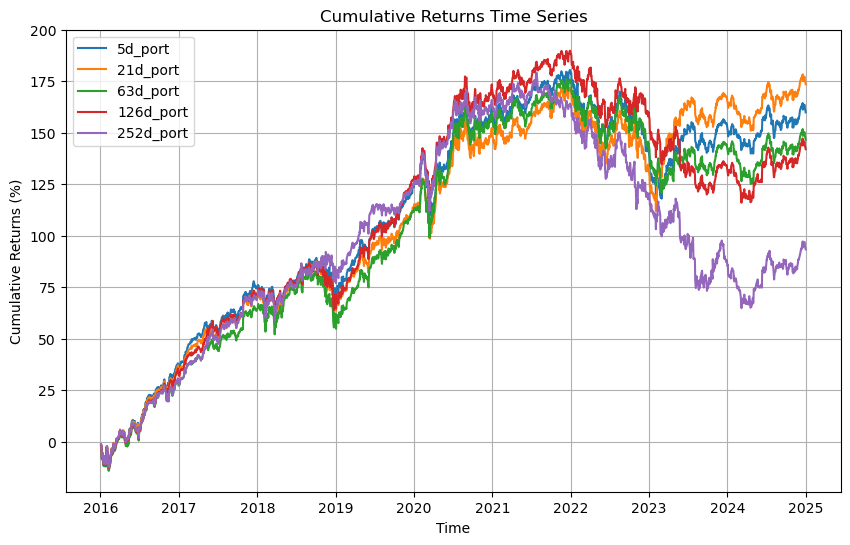

In [22]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(portfolios_df.cumsum().mul(100), label=portfolios_df.columns, alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns (%)')
plt.legend()

# Show
plt.grid(True)
plt.show()

### Comparing Portfolios ###

In [23]:
# Now the table
analytics_table = calculate_analytics(portfolios_df)

analytics_table

,Annualized Returns,Annualized Volatility,Sharpe Ratio,Max Drawdown,VaR 95%
5d_port,17.799870,25.720807,0.692042,-1.0,-2.583603
21d_port,19.315730,25.883303,0.746262,-1.0,-2.607800
63d_port,16.315076,25.569053,0.638079,-1.0,-2.632700
126d_port,15.808771,26.306600,0.600943,-1.0,-2.686195
252d_port,10.394208,27.083612,0.383782,-1.0,-2.838919


### Constraining Weights ###

The problem is that we cannot create large portfolios (with many components) using this methodology because, sometimes, many assets will have high levels of leverage. Therefore, we can use other methods:

In [24]:
# Portfolio Variance
def portfolio_variance(w, covariance_matrix):
    return w.T @ covariance_matrix @ w


# Constraint: Sum of weights equal one
def constraint_sum_weights(w):
    return np.sum(w) - 1


# Constraint: Returns equation
def constraint_target_return(w, expected_returns, target_return):
    return w.T @ expected_returns - target_return


# Optimization
def markowitz_optimization(
        expected_returns,
        covariance_matrix,
        target_return
):
    # Initial Weights
    n = len(expected_returns)
    w0 = np.ones(n) / n

    # Set constraints
    constraints = [
        {'type': 'eq', 'fun': constraint_sum_weights},
        {'type': 'eq', 'fun': lambda w: constraint_target_return(w, expected_returns, target_return)}
    ]

    # Set bounds (-1 if allow shorting, 0 if not)
    bounds = [(-1, 1) for _ in range(n)]

    result = minimize(
        portfolio_variance,
        w0,
        args=(covariance_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x
    else:
        raise ValueError("Optimization failed: " + result.message)

In [25]:
# Import Data
universe_returns = pd.read_csv(r'../additional_data/stocks_returns.csv')
universe_returns = universe_returns.rename(columns={'Unnamed: 0':'Date'})
universe_returns.set_index('Date', inplace=True)
universe_returns.index = pd.to_datetime(universe_returns.index)
universe_returns = universe_returns.dropna(axis=1)

# Use data from 2015
universe_returns = universe_returns.loc['2015':]

universe_returns

,AAPL,ABT,ACGL,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,...,WST,WY,X,XEL,XOM,XRAY,XRX,YUM,ZBRA,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,-0.009558,-0.002669,-0.010375,-0.004964,0.000360,0.000385,-0.000960,-0.008864,-0.003040,0.007057,...,-0.020494,0.006111,-0.005625,0.005553,0.004102,-0.025477,-0.007968,-0.006887,0.000258,-0.007747
2015-01-05,-0.028576,0.000223,-0.006002,-0.004989,-0.018352,-0.035215,-0.000720,-0.014722,-0.010053,-0.014827,...,-0.013900,0.000000,-0.047756,-0.011416,-0.027743,-0.006957,-0.022060,-0.020527,-0.014177,-0.038189
2015-01-06,0.000094,-0.011421,0.002233,-0.020350,-0.023753,-0.019910,-0.008325,-0.019973,-0.011709,0.005462,...,-0.017255,-0.001108,-0.030846,0.005307,-0.005331,-0.012488,-0.013473,-0.012350,-0.007231,-0.038942
2015-01-07,0.013925,0.008075,0.005818,0.008190,0.010462,0.014920,0.008685,-0.002089,0.007748,0.014096,...,0.016088,0.003045,0.002438,0.008598,0.010082,0.025588,0.012729,0.032601,0.025146,0.009501
2015-01-08,0.037702,0.020346,0.017254,0.025135,0.017501,-0.014717,0.022681,0.024446,0.003522,0.008589,...,0.019466,0.010722,0.021679,0.011533,0.016508,0.024389,0.027158,0.017270,0.021134,0.013897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011413,0.003929,0.006278,0.002683,0.014781,0.004355,0.007822,0.012494,0.013291,-0.005291,...,0.009663,0.006390,0.018946,0.007210,0.000940,-0.002642,-0.023556,0.008480,0.012187,0.010791
2024-12-26,0.003171,0.004434,0.002802,0.004944,-0.000138,-0.000395,0.002594,-0.003159,-0.002203,-0.003362,...,0.001981,-0.003190,-0.030811,-0.000440,0.000845,0.013663,-0.006522,0.007380,0.003559,0.006889
2024-12-27,-0.013331,-0.002432,-0.006369,-0.008208,-0.004919,-0.000593,-0.003539,-0.008999,-0.006305,0.004876,...,-0.000630,-0.006410,0.004506,-0.000587,-0.000094,-0.003163,-0.002183,-0.005678,-0.019799,-0.012179


In [26]:
# Components:
mean_returns = universe_returns.loc['2015'].mean()
cov_matrix = universe_returns.loc['2015'].cov()

In [27]:
unrestricted_weights = markowitz_weights(mean_returns, cov_matrix, 0.0003)
unrestricted_weights = pd.Series(unrestricted_weights, index = universe_returns.columns)
unrestricted_weights.name = 'weights'
unrestricted_weights = unrestricted_weights/1000

unrestricted_weights

AAPL   -0.014404
ABT     0.047199
ACGL   -0.076627
ADBE   -0.011729
ADI     0.013170
          ...   
XRAY    0.008874
XRX     0.042891
YUM     0.035161
ZBRA   -0.006732
ZION   -0.001393
Name: weights, Length: 435, dtype: float64

In [28]:
restricted_weights = markowitz_optimization(mean_returns, cov_matrix, 0.0003)
restricted_weights = pd.Series(restricted_weights, index = universe_returns.columns)
restricted_weights.name = 'weights'

restricted_weights

AAPL    0.002321
ABT     0.002497
ACGL    0.003169
ADBE    0.003447
ADI     0.002486
          ...   
XRAY    0.003007
XRX     0.001468
YUM     0.002547
ZBRA    0.001968
ZION    0.002266
Name: weights, Length: 435, dtype: float64

In [29]:
unrestricted_portfolio = universe_returns.loc['2016':] @ unrestricted_weights
unrestricted_portfolio.name = 'unrestricted_portfolio'

unrestricted_portfolio

Date
2016-01-04   -0.009188
2016-01-05    0.001596
2016-01-06   -0.012072
2016-01-07    0.013439
2016-01-08    0.004701
                ...   
2024-12-24   -0.001263
2024-12-26    0.004346
2024-12-27    0.005005
2024-12-30   -0.007087
2024-12-31    0.007952
Name: unrestricted_portfolio, Length: 2264, dtype: float64

In [30]:
restricted_portfolio = universe_returns.loc['2016':] @ restricted_weights
restricted_portfolio.name = 'restricted_portfolio'

restricted_portfolio

Date
2016-01-04   -0.016466
2016-01-05    0.002578
2016-01-06   -0.012984
2016-01-07   -0.022289
2016-01-08   -0.012233
                ...   
2024-12-24    0.006598
2024-12-26    0.002338
2024-12-27   -0.006908
2024-12-30   -0.008353
2024-12-31    0.003088
Name: restricted_portfolio, Length: 2264, dtype: float64

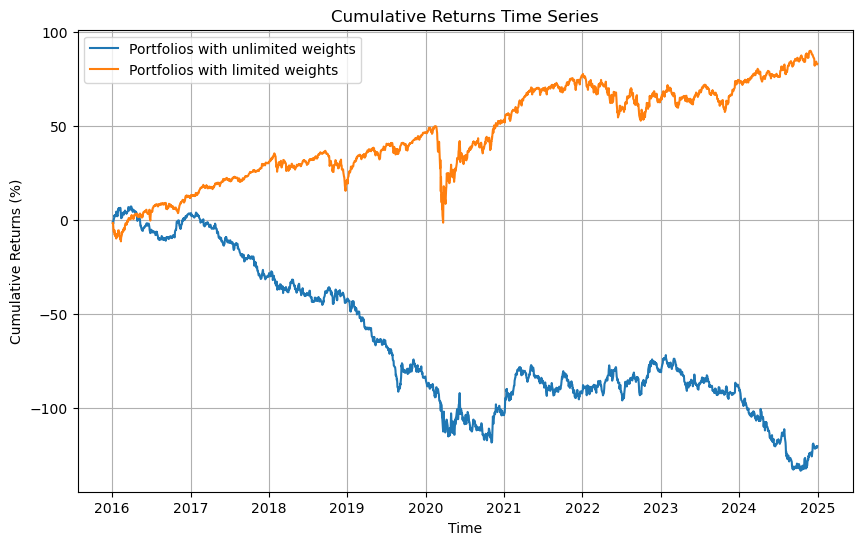

In [31]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(unrestricted_portfolio.cumsum().mul(100), label='Portfolios with unlimited weights', alpha=1)
plt.plot(restricted_portfolio.cumsum().mul(100), label='Portfolios with limited weights', alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns (%)')
plt.legend()

# Show
plt.grid(True)
plt.show()

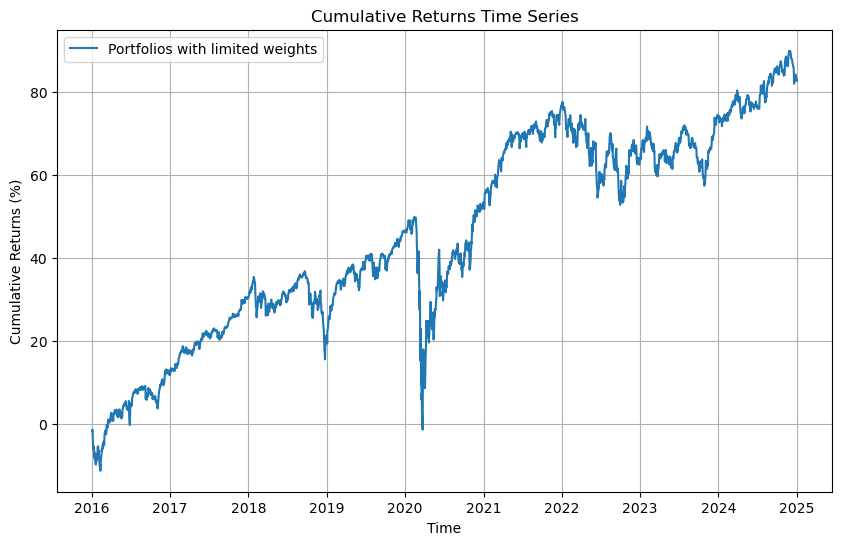

In [32]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(restricted_portfolio.cumsum().mul(100), label='Portfolios with limited weights', alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns (%)')
plt.legend()

# Show
plt.grid(True)
plt.show()

In [33]:
# Create the analytics
limit_portfolios = pd.DataFrame(index=restricted_portfolio.index)

limit_portfolios['unrestricted_portfolio'] = unrestricted_portfolio
limit_portfolios['restricted_portfolio'] = restricted_portfolio

limit_portfolios

,unrestricted_portfolio,restricted_portfolio
Date,,
2016-01-04,-0.009188,-0.016466
2016-01-05,0.001596,0.002578
2016-01-06,-0.012072,-0.012984
2016-01-07,0.013439,-0.022289
2016-01-08,0.004701,-0.012233
...,...,...
2024-12-24,-0.001263,0.006598
2024-12-26,0.004346,0.002338
2024-12-27,0.005005,-0.006908


In [34]:
calculate_analytics(limit_portfolios)

,Annualized Returns,Annualized Volatility,Sharpe Ratio,Max Drawdown,VaR 95%
unrestricted_portfolio,-13.368783,19.870152,-0.672807,-1.0,-1.991296
restricted_portfolio,9.237321,18.400838,0.502005,-1.0,-1.641541


### Compare with a Portfolio with Rebalancing and No Survivorship Bias ###

In [35]:
# Import Data
real_portfolio = pd.read_csv(r'../additional_data/markowitz_portfolio.csv')
real_portfolio = real_portfolio.rename(columns={'Unnamed: 0':'Date'})
real_portfolio.set_index('Date', inplace=True)
real_portfolio.index = pd.to_datetime(real_portfolio.index)

# Use data from 2016
real_portfolio = real_portfolio.loc['2016':]

real_portfolio

,portfolio_returns
Date,
2016-01-04,-0.013036
2016-01-05,0.001206
2016-01-06,-0.017725
2016-01-07,-0.025410
2016-01-08,-0.012495
...,...
2024-12-24,0.006201
2024-12-26,0.000034
2024-12-27,-0.002855


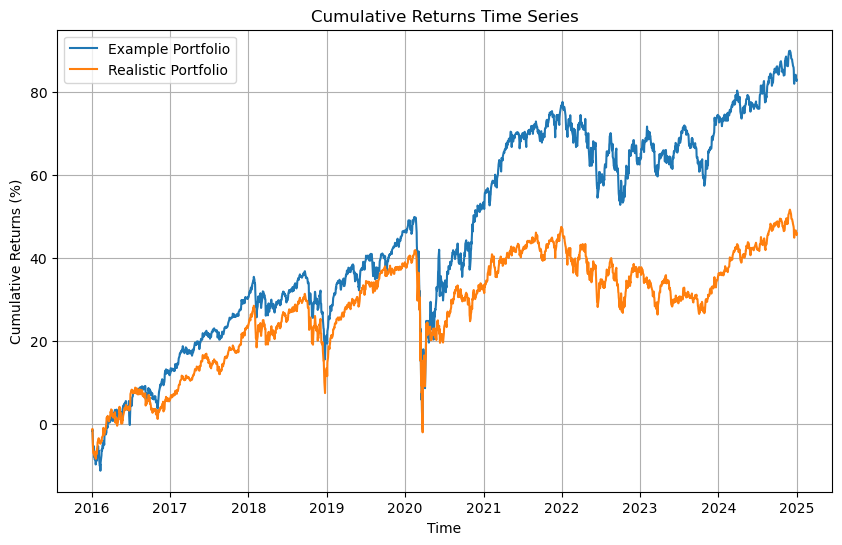

In [36]:
# Time Series Graphs
plt.figure(figsize=(10, 6))
plt.plot(restricted_portfolio.cumsum().mul(100), label='Example Portfolio', alpha=1)
plt.plot(real_portfolio.cumsum().mul(100), label='Realistic Portfolio', alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns (%)')
plt.legend()

# Show
plt.grid(True)
plt.show()

The difference in returns can be explained by the survivorship bias (and the re-balancing factor)